In [1]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

import pandas as pd

from src.cleaning import clean_transactions
from src.fuzzy_grouping import group_merchants

from src.eda import (
    spending_by_category,
    average_monthly_spending_by_category,
    spending_by_merchant,
    average_monthly_spending_by_merchant,
    monthly_spending,
    average_monthly_spending
)

from src.visualization import (
    plot_category_spending,
    plot_avg_monthly_category_spending,
    plot_top_merchants,
    plot_avg_monthly_merchants,
    plot_monthly_spending
)

In [2]:
df = clean_transactions("../data/Discover_Transaction_History.csv")

print(f"Rows loaded: {len(df):,}")
print(f"Unique descriptions: {df['description'].nunique():,}")

Rows loaded: 3,286
Unique descriptions: 1,403


/Users/mafphd/personalprojects/src/cleaning.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["trans_date"] = pd.to_datetime(df["trans_date"], errors="coerce")
/Users/mafphd/personalprojects/src/cleaning.py:54: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["post_date"] = pd.to_datetime(df["post_date"], errors="coerce")


In [3]:
df.head()

,trans_date,post_date,description,amount,category,desc_clean,month,day_of_week,is_weekend
0,2023-10-17,2023-10-19,WALGREENS #10196 WAUWATOSA WI,13.70,Merchandise,WALGREENS WAUWATOSA,2023-10,Tuesday,False
1,2023-10-18,2023-10-19,5-365 FOOD SERVICE TROY MI,3.05,Restaurants,FOOD SERVICE TROY MI,2023-10,Wednesday,False
2,2023-10-18,2023-10-19,QUALITY HEATING AND SHEE BROOKFIELD WI,79.65,Services,QUALITY HEATING AND SHEE BROOKFIELD,2023-10,Wednesday,False
3,2023-10-18,2023-10-19,SOMMER'S INC. MEQUON WI649149,114.59,Automotive,SOMMERS INC MEQUON,2023-10,Wednesday,False
4,2023-10-19,2023-10-19,MILTOWN EATS LLC 4144349799 WI,30.00,Supermarkets,MILTOWN EATS,2023-10,Thursday,False


In [4]:
df = group_merchants(
    df,
    threshold=85,
    max_words=2
)

print(f"Unique merchant groups: {df['merchant_clean'].nunique():,}")

Unique merchant groups: 706


In [5]:
(
    df[[
        "description",
        "desc_clean",
        "merchant_clean"
    ]]
    .sort_values("merchant_clean")
    .head(50)
)

,description,desc_clean,merchant_clean
2483,AAA ACG NE0069 EFT RCC 800-222-1134 MI,AAA ACG NE EFT RCC MI,AAA ACG
1238,AAA ACG NE0069 EFT RCC 800-222-1134 MI,AAA ACG NE EFT RCC MI,AAA ACG
45,AAA ACG NE0069 EFT RCC 800-222-1134 MI,AAA ACG NE EFT RCC MI,AAA ACG
17,AAA INSURANCE GW EFT 800-222-6424 MI,AAA INSURANCE GW EFT MI,AAA INSURANCE
1880,AAA INSURANCE GW EFT 800-222-6424 MI,AAA INSURANCE GW EFT MI,AAA INSURANCE
2466,AAA INSURANCE GW EFT 800-222-6424 MI,AAA INSURANCE GW EFT MI,AAA INSURANCE
1220,AAA INSURANCE GW EFT 800-222-6424 MI,AAA INSURANCE GW EFT MI,AAA INSURANCE
596,AAA INSURANCE GW EFT 800-222-6424 MI,AAA INSURANCE GW EFT MI,AAA INSURANCE
597,AAA INSURANCE GW EFT 800-222-6424 MI,AAA INSURANCE GW EFT MI,AAA INSURANCE
1879,AAA INSURANCE GW EFT 800-222-6424 MI,AAA INSURANCE GW EFT MI,AAA INSURANCE


In [6]:
category_totals = spending_by_category(df)

category_totals.head(20)

,category,total_spend
9,Services,42305.58
7,Merchandise,40197.25
8,Restaurants,29706.20
11,Travel/ Entertainment,26477.51
10,Supermarkets,21910.82
2,Education,7477.32
5,Home Improvement,5144.33
0,Automotive,5049.15
6,Medical Services,3224.61
4,Government Services,1857.74


In [7]:
merchant_totals = spending_by_merchant(df)

merchant_totals.head(25)

,merchant_clean,total_spend
30,APPLIANCE GALLERY,10123.51
83,CENTRAL BARKBROOKFIELD,8127.07
281,LEGACY GYM,7065.40
513,SENDIKS WAUWATOSA,6230.94
1,AAA INSURANCE,5095.03
350,MILTOWN EATS,4436.98
533,SOMMERS AUTOMOTIVE,3138.67
260,JULIES PARK,3096.68
352,MILWAUKEE ELECTRIC,2819.33
571,SPECTRUM MORC,2713.77


In [8]:
merchant_avg_monthly = average_monthly_spending_by_merchant(df)

merchant_avg_monthly.head(25)

,merchant_clean,avg_monthly_spend
30,APPLIANCE GALLERY,306.773030
83,CENTRAL BARKBROOKFIELD,246.274848
281,LEGACY GYM,214.103030
513,SENDIKS WAUWATOSA,188.816364
1,AAA INSURANCE,154.394848
350,MILTOWN EATS,134.453939
533,SOMMERS AUTOMOTIVE,95.111212
260,JULIES PARK,93.838788
352,MILWAUKEE ELECTRIC,85.434242
571,SPECTRUM MORC,82.235455


In [9]:
monthly_totals = monthly_spending(df)

monthly_totals

,month,monthly_spend
0,2023-10-01,2817.69
1,2023-11-01,4416.13
2,2023-12-01,5457.43
3,2024-01-01,3387.57
4,2024-02-01,5055.45
5,2024-03-01,5455.23
6,2024-04-01,6413.21
7,2024-05-01,5719.73
8,2024-06-01,5691.82
9,2024-07-01,6782.19


In [10]:
overall_monthly_average = average_monthly_spending(df)

print(
    f"Average Monthly Spending: "
    f"${overall_monthly_average:,.2f}"
)

Average Monthly Spending: $5,578.96


/Users/mafphd/personalprojects/src/visualization.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


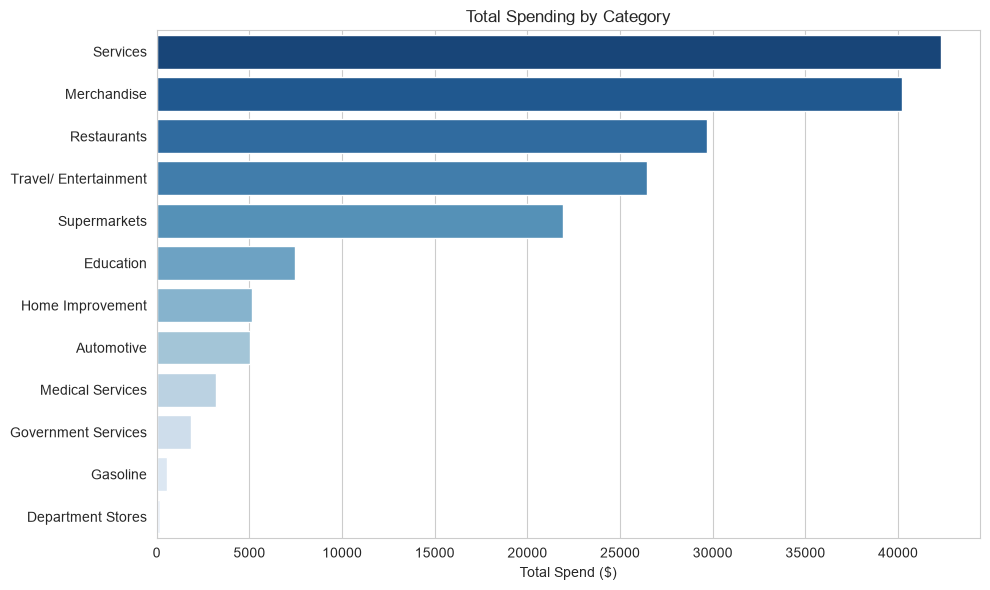

In [11]:
plot_category_spending(
    category_totals
)

/Users/mafphd/personalprojects/src/visualization.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


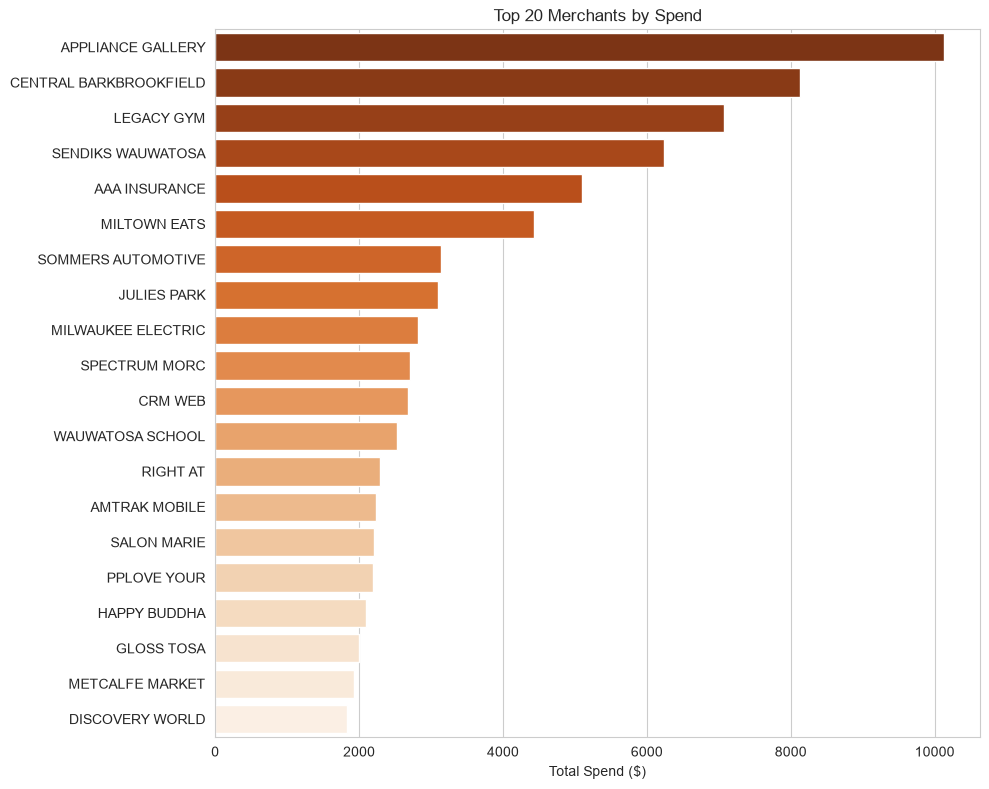

In [12]:
plot_top_merchants(
    merchant_totals,
    top_n=20
)

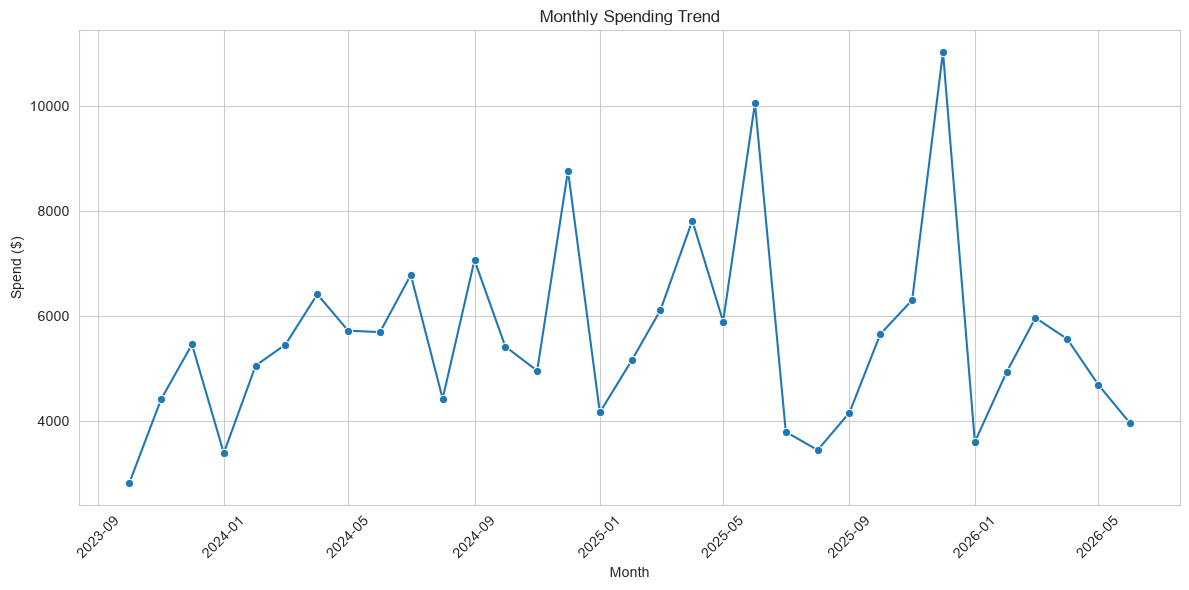

In [13]:
plot_monthly_spending(
    monthly_totals
)

In [14]:
merchant_summary = (
    df.groupby("merchant_clean")
      .agg(
          transaction_count=("amount", "count"),
          active_months=("month", "nunique"),
          total_spend=("amount", "sum"),
          average_transaction=("amount", "mean")
      )
)

total_months = df["month"].nunique()

merchant_summary["avg_monthly_spend"] = (
    merchant_summary["total_spend"] / total_months
)

merchant_summary["monthly_frequency"] = (
    merchant_summary["active_months"] / total_months
)

merchant_summary.sort_values(
    "avg_monthly_spend",
    ascending=False
)

,transaction_count,active_months,total_spend,average_transaction,avg_monthly_spend,monthly_frequency
merchant_clean,,,,,,
APPLIANCE GALLERY,2,2,10123.51,5061.755000,306.773030,0.060606
CENTRAL BARKBROOKFIELD,189,32,8127.07,43.000370,246.274848,0.969697
LEGACY GYM,75,32,7065.40,94.205333,214.103030,0.969697
SENDIKS WAUWATOSA,159,33,6230.94,39.188302,188.816364,1.000000
AAA INSURANCE,7,5,5095.03,727.861429,154.394848,0.151515
...,...,...,...,...,...,...
HIEBERS PHARMACY,1,1,2.45,2.450000,0.074242,0.030303
JILLYS CAR,1,1,2.00,2.000000,0.060606,0.030303
PARKMOBILE APPLE,1,1,2.00,2.000000,0.060606,0.030303


In [17]:
with pd.ExcelWriter(
    "../outputs/spending_summary.xlsx",
    engine="openpyxl"
) as writer:

    category_totals.to_excel(
        writer,
        sheet_name="Category Totals",
        index=False
    )

    category_avg_monthly.to_excel(
        writer,
        sheet_name="Category Monthly Avg",
        index=False
    )

    merchant_totals.to_excel(
        writer,
        sheet_name="Merchant Totals",
        index=False
    )

    merchant_avg_monthly.to_excel(
        writer,
        sheet_name="Merchant Monthly Avg",
        index=False
    )

    merchant_summary.to_excel(
        writer,
        sheet_name="Merchant Summary",
        index=False
    )

    monthly_totals.to_excel(
        writer,
        sheet_name="Monthly Spending",
        index=False
    )

print("Results exported.")

NameError: name 'category_avg_monthly' is not defined